# Dimensionality Reduction: PCA vs LDA

**Dataset:** Wine (sklearn built-in)  
**Goal:** Reduce 13 features down to 2 dimensions using two different techniques and compare the results  

| Technique | Type | Objective |
|-----------|------|-----------|
| **PCA** — Principal Component Analysis | Unsupervised | Maximize variance in the data |
| **LDA** — Linear Discriminant Analysis | Supervised | Maximize class separability |

## 1. Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

## 2. Load Dataset

The **Wine dataset** contains chemical measurements of 178 wines from 3 cultivars grown in Italy.  
With 13 features it is a good candidate for dimensionality reduction.

### Feature Descriptions

| Column | Description |
|--------|-------------|
| `alcohol` | Alcohol content (% by volume) |
| `malic_acid` | Malic acid concentration — contributes to the tartness/sourness of wine |
| `ash` | Inorganic residue remaining after wine is burned — reflects mineral content |
| `alcalinity_of_ash` | How alkaline the ash is — related to buffering capacity and mineral balance |
| `magnesium` | Magnesium content (mg/L) — a mineral absorbed from soil during grape growth |
| `total_phenols` | Total amount of phenolic compounds — linked to antioxidants and bitterness |
| `flavanoids` | A subgroup of phenols — major contributors to color, taste, and health properties |
| `nonflavanoid_phenols` | Phenolic compounds that are **not** flavanoids (e.g., acids) — smaller fraction |
| `proanthocyanins` | A class of flavanoids responsible for astringency and red/purple color |
| `color_intensity` | How deep/dark the color of the wine is |
| `hue` | The shade/tone of color — ratio of specific absorbances in the wine |
| `od280/od315_of_diluted_wines` | Optical density ratio — a standard lab measure of protein/phenol content |
| `proline` | An amino acid found in grapes — concentration varies by cultivar and region |
| `target` | Wine cultivar class: 0, 1, or 2 |

In [3]:
wine = load_wine()

df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target
df['class'] = df['target'].map({0: 'Class 0', 1: 'Class 1', 2: 'Class 2'})

print('Shape:', df.shape)
print('Features:', wine.feature_names)
print('Classes:', wine.target_names)
df.head()

Shape: (178, 15)
Features: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Classes: ['class_0' 'class_1' 'class_2']


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,Class 0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,Class 0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,Class 0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,Class 0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,Class 0


## 3. Exploratory Data Analysis

In [4]:
df[wine.feature_names].describe().round(2)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00
mean,13.00,2.34,2.37,19.49,99.74,2.30,2.03,0.36,1.59,5.06,0.96,2.61,746.89
std,0.81,1.12,0.27,3.34,14.28,0.63,1.00,0.12,0.57,2.32,0.23,0.71,314.91
min,11.03,0.74,1.36,10.60,70.00,0.98,0.34,0.13,0.41,1.28,0.48,1.27,278.00
25%,12.36,1.60,2.21,17.20,88.00,1.74,1.20,0.27,1.25,3.22,0.78,1.94,500.50
50%,13.05,1.87,2.36,19.50,98.00,2.36,2.13,0.34,1.56,4.69,0.96,2.78,673.50
75%,13.68,3.08,2.56,21.50,107.00,2.80,2.88,0.44,1.95,6.20,1.12,3.17,985.00
max,14.83,5.80,3.23,30.00,162.00,3.88,5.08,0.66,3.58,13.00,1.71,4.00,1680.00


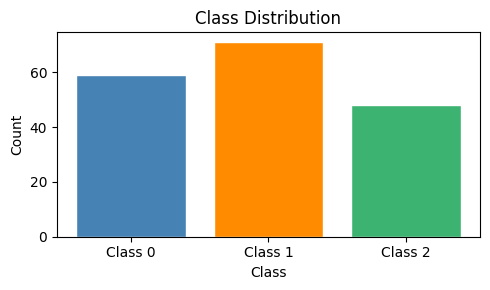

In [5]:
# Class distribution
counts = df['class'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(counts.index, counts.values, color=['steelblue', 'darkorange', 'mediumseagreen'], edgecolor='white')
ax.set_title('Class Distribution')
ax.set_xlabel('Class')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

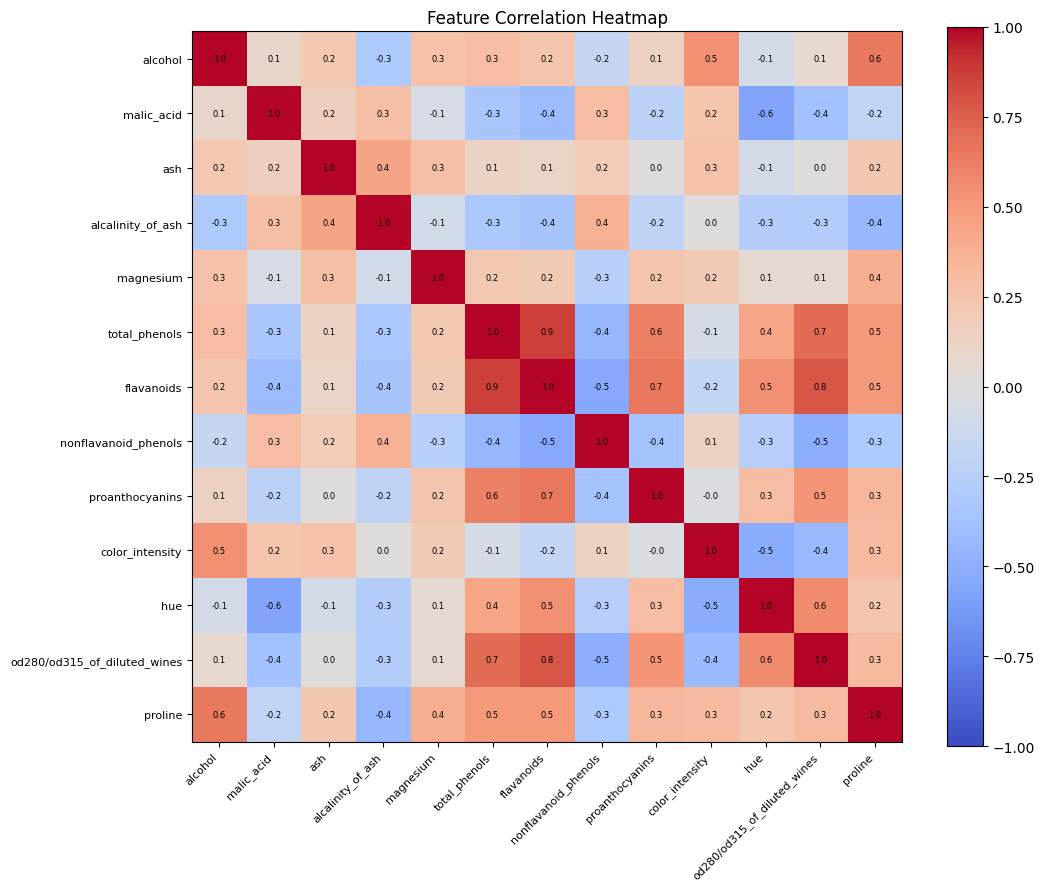

In [6]:
# Correlation heatmap
corr = df[wine.feature_names].corr()

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(wine.feature_names)))
ax.set_yticks(range(len(wine.feature_names)))
ax.set_xticklabels(wine.feature_names, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(wine.feature_names, fontsize=8)
for i in range(len(wine.feature_names)):
    for j in range(len(wine.feature_names)):
        ax.text(j, i, f'{corr.iloc[i, j]:.1f}', ha='center', va='center', fontsize=6)
ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

Both PCA and LDA are sensitive to feature scale.  
Features with larger ranges dominate the result if not standardized.

In [7]:
X = df[wine.feature_names].values
y = df['target'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('X shape:', X_scaled.shape)
print('Scaled mean (approx 0):', X_scaled.mean(axis=0).round(10))
print('Scaled std  (approx 1):', X_scaled.std(axis=0).round(10))

X shape: (178, 13)
Scaled mean (approx 0): [-0. -0. -0. -0. -0.  0. -0.  0. -0.  0.  0.  0. -0.]
Scaled std  (approx 1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


---
## 5. PCA — Principal Component Analysis

**How it works:**
1. Compute the covariance matrix of the scaled features.
2. Find the **eigenvectors** (principal components) and **eigenvalues** of that matrix.
3. Sort components by eigenvalue (highest variance first).
4. Project the data onto the top K components.

PCA is **unsupervised** — it ignores class labels and only looks at the spread of the data.

### 5.1 Fit PCA on All 13 Components

In [8]:
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

print('Explained variance ratio per component:')
for i, (ev, cum) in enumerate(zip(explained, cumulative)):
    print(f'  PC{i+1:>2}: {ev:.4f}  (cumulative: {cum:.4f})')

Explained variance ratio per component:
  PC 1: 0.3620  (cumulative: 0.3620)
  PC 2: 0.1921  (cumulative: 0.5541)
  PC 3: 0.1112  (cumulative: 0.6653)
  PC 4: 0.0707  (cumulative: 0.7360)
  PC 5: 0.0656  (cumulative: 0.8016)
  PC 6: 0.0494  (cumulative: 0.8510)
  PC 7: 0.0424  (cumulative: 0.8934)
  PC 8: 0.0268  (cumulative: 0.9202)
  PC 9: 0.0222  (cumulative: 0.9424)
  PC10: 0.0193  (cumulative: 0.9617)
  PC11: 0.0174  (cumulative: 0.9791)
  PC12: 0.0130  (cumulative: 0.9920)
  PC13: 0.0080  (cumulative: 1.0000)


### 5.2 Scree Plot & Cumulative Variance

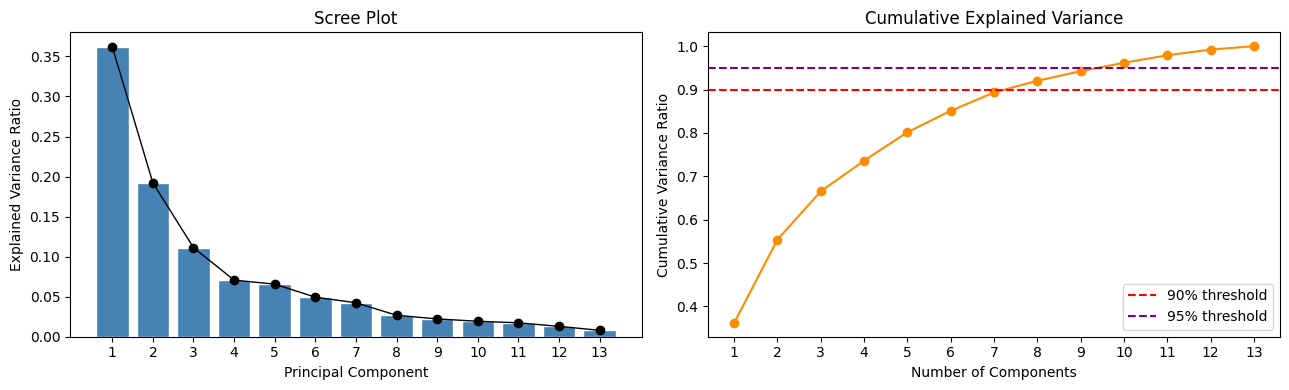

Components needed for 90% variance: 8
Components needed for 95% variance: 10


In [9]:
n = len(explained)
x_ticks = range(1, n + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Scree plot
axes[0].bar(x_ticks, explained, color='steelblue', edgecolor='white')
axes[0].plot(x_ticks, explained, marker='o', color='black', linewidth=1)
axes[0].set_title('Scree Plot')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_xticks(x_ticks)

# Cumulative variance
axes[1].plot(x_ticks, cumulative, marker='o', color='darkorange')
axes[1].axhline(y=0.90, color='red', linestyle='--', label='90% threshold')
axes[1].axhline(y=0.95, color='purple', linestyle='--', label='95% threshold')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance Ratio')
axes[1].set_xticks(x_ticks)
axes[1].legend()

plt.tight_layout()
plt.show()

n90 = np.argmax(cumulative >= 0.90) + 1
n95 = np.argmax(cumulative >= 0.95) + 1
print(f'Components needed for 90% variance: {n90}')
print(f'Components needed for 95% variance: {n95}')

### 5.3 Project to 2D

In [10]:
pca2 = PCA(n_components=2, random_state=42)
X_pca = pca2.fit_transform(X_scaled)

print('Reduced shape:', X_pca.shape)
print(f'Variance explained by PC1+PC2: {pca2.explained_variance_ratio_.sum():.4f}')

Reduced shape: (178, 2)
Variance explained by PC1+PC2: 0.5541


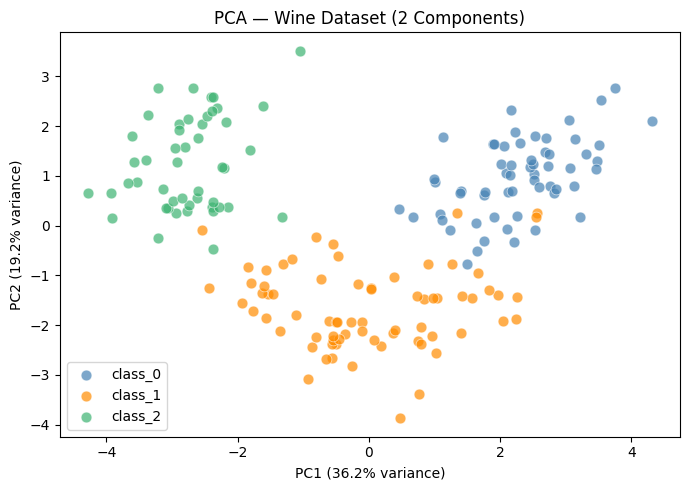

In [11]:
colors = ['steelblue', 'darkorange', 'mediumseagreen']
class_names = wine.target_names

fig, ax = plt.subplots(figsize=(7, 5))
for i, (cls, col) in enumerate(zip(class_names, colors)):
    mask = y == i
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               label=cls, color=col, alpha=0.7, s=60, edgecolors='white', linewidths=0.5)

var1, var2 = pca2.explained_variance_ratio_ * 100
ax.set_xlabel(f'PC1 ({var1:.1f}% variance)')
ax.set_ylabel(f'PC2 ({var2:.1f}% variance)')
ax.set_title('PCA — Wine Dataset (2 Components)')
ax.legend()
plt.tight_layout()
plt.show()

### 5.4 Component Loadings

The **loadings** show how much each original feature contributes to each principal component.  
Large absolute values indicate high influence.

In [12]:
loadings = pd.DataFrame(
    pca2.components_.T,
    index=wine.feature_names,
    columns=['PC1', 'PC2']
).round(3)

print('Component Loadings:')
loadings

Component Loadings:


,PC1,PC2
alcohol,0.144,0.484
malic_acid,-0.245,0.225
ash,-0.002,0.316
alcalinity_of_ash,-0.239,-0.011
magnesium,0.142,0.300
total_phenols,0.395,0.065
flavanoids,0.423,-0.003
nonflavanoid_phenols,-0.299,0.029
proanthocyanins,0.313,0.039
color_intensity,-0.089,0.530


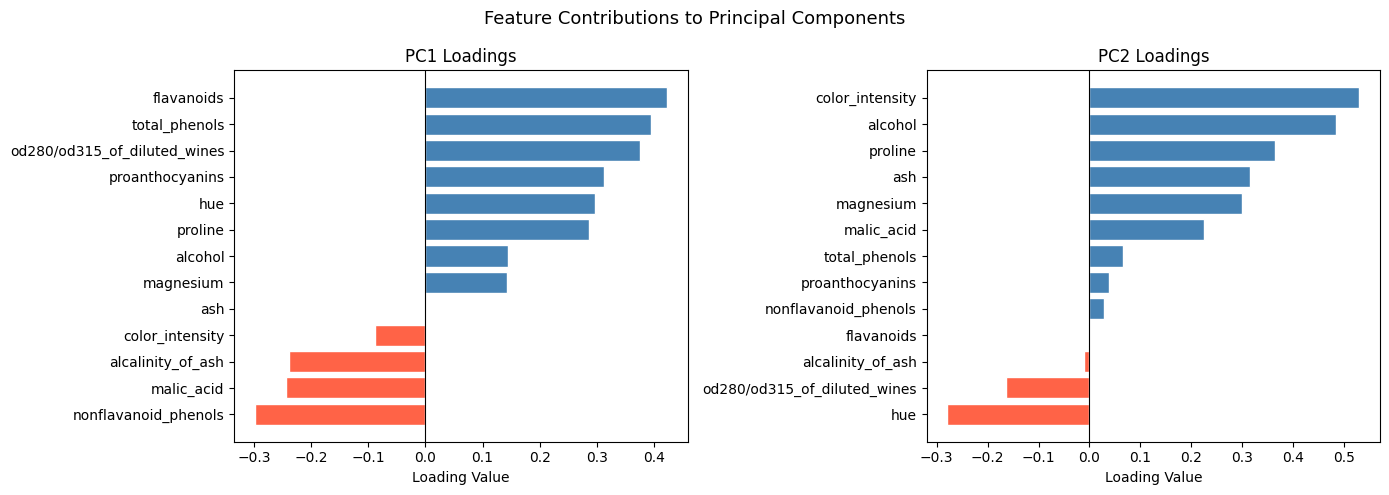

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, pc in zip(axes, ['PC1', 'PC2']):
    vals = loadings[pc].sort_values()
    bar_colors = ['steelblue' if v >= 0 else 'tomato' for v in vals]
    ax.barh(vals.index, vals.values, color=bar_colors, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{pc} Loadings')
    ax.set_xlabel('Loading Value')

plt.suptitle('Feature Contributions to Principal Components', fontsize=13)
plt.tight_layout()
plt.show()

---
## 6. LDA — Linear Discriminant Analysis

**How it works:**
1. Compute the **within-class scatter matrix** $S_W$ and **between-class scatter matrix** $S_B$.
2. Find the axes that **maximize** $S_B / S_W$ — i.e., large separation between classes, small spread within classes.
3. The number of discriminant components is at most $\min(n\_classes - 1,\ n\_features)$.

LDA is **supervised** — it uses class labels directly to find the best projection.  
For 3 classes (Wine), we get at most **2 linear discriminants** (LD1, LD2).

> LDA assumes normally distributed features with equal class covariances.

### 6.1 Fit LDA

In [14]:
lda = LDA(n_components=2)
X_lda = lda.fit_transform(X_scaled, y)

print('Reduced shape:', X_lda.shape)

explained_lda = lda.explained_variance_ratio_
print(f'LD1 explained variance: {explained_lda[0]:.4f}')
print(f'LD2 explained variance: {explained_lda[1]:.4f}')
print(f'Total explained: {explained_lda.sum():.4f}')

Reduced shape: (178, 2)
LD1 explained variance: 0.6875
LD2 explained variance: 0.3125
Total explained: 1.0000


### 6.2 2D Scatter

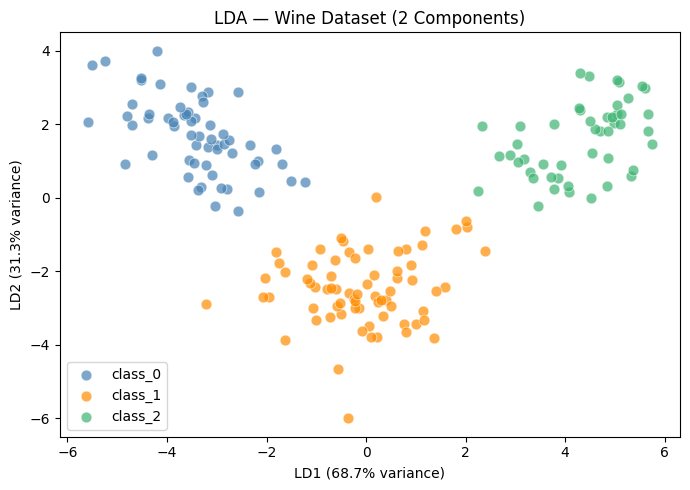

In [15]:
fig, ax = plt.subplots(figsize=(7, 5))
for i, (cls, col) in enumerate(zip(class_names, colors)):
    mask = y == i
    ax.scatter(X_lda[mask, 0], X_lda[mask, 1],
               label=cls, color=col, alpha=0.7, s=60, edgecolors='white', linewidths=0.5)

ld1_var, ld2_var = lda.explained_variance_ratio_ * 100
ax.set_xlabel(f'LD1 ({ld1_var:.1f}% variance)')
ax.set_ylabel(f'LD2 ({ld2_var:.1f}% variance)')
ax.set_title('LDA — Wine Dataset (2 Components)')
ax.legend()
plt.tight_layout()
plt.show()

---
## 7. PCA vs LDA — Side-by-Side Comparison

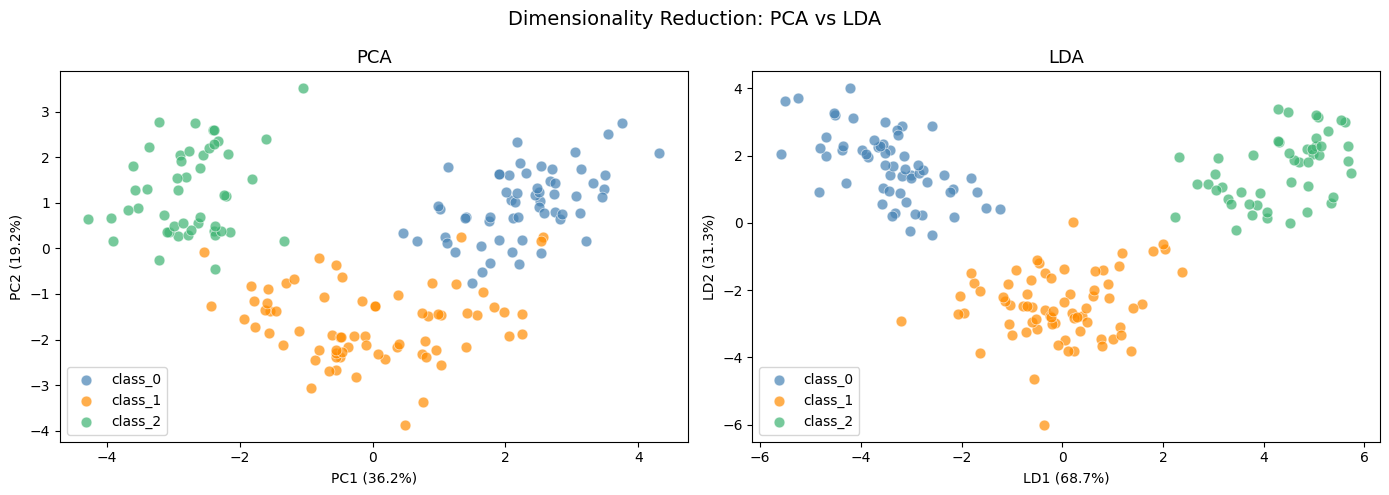

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

datasets = [
    (X_pca, 'PCA', f'PC1 ({var1:.1f}%)', f'PC2 ({var2:.1f}%)'),
    (X_lda, 'LDA', f'LD1 ({ld1_var:.1f}%)', f'LD2 ({ld2_var:.1f}%)')
]

for ax, (X_red, title, xlabel, ylabel) in zip(axes, datasets):
    for i, (cls, col) in enumerate(zip(class_names, colors)):
        mask = y == i
        ax.scatter(X_red[mask, 0], X_red[mask, 1],
                   label=cls, color=col, alpha=0.7, s=60, edgecolors='white', linewidths=0.5)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend()

plt.suptitle('Dimensionality Reduction: PCA vs LDA', fontsize=14)
plt.tight_layout()
plt.show()

---
## 8. Summary

### Key Observations

| | PCA | LDA |
|-|-----|-----|
| **Type** | Unsupervised | Supervised |
| **Objective** | Maximize total variance | Maximize class separation |
| **Uses labels?** | No | Yes |
| **Max components** | min(n_samples, n_features) | n_classes − 1 |
| **Variance captured (2D)** | ~55% | ~100% of discriminant variance |
| **Class separation (Wine)** | Moderate | Much cleaner |

### When to Use Each

- **Use PCA** when you have no labels, want to explore data structure, or need to reduce noise before modeling.
- **Use LDA** when you have labeled data and want the best 2D view for classification tasks.
- PCA preserves **global structure**; LDA preserves **class boundaries**.